In [1]:
import torch
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [6]:
transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(dtype=torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size=4

classes = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

In [7]:
train_set = torchvision.datasets.CIFAR10('./data', train=True, download=False, transform=transforms)
train_set, val_set = torch.utils.data.random_split(train_set, [35000, 15000])
test_set = torchvision.datasets.CIFAR10('./data', train=False, download=False, transform=transforms)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

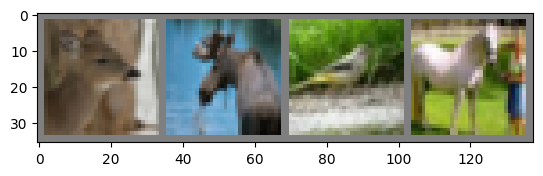

deer deer bird horse


In [13]:
def imshow(img):
    #Un-normalize the image
    img = img/2 + 0.5
    #Visualize numpy array
    np_img = img.numpy()
    #Transpose to shape input
    np_img = np.transpose(np_img, (1,2,0))
    plt.imshow(np_img)
    plt.show()

images, labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(images)
imshow(grid)
print(" ".join(f'{classes[labels[j]]}' for j in range(batch_size)))

In [ ]:
# Create the model
class CNN(torch.nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.relu = torch.nn.ReLU()
        self.conv1 = torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = torch.nn.MaxPool2d(2,2)
        self.fc = torch.nn.Linear(in_features=8*8*32, out_features = num_classes)
        
    def forward(self, x):
        #Apply first conv layer and activate
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        #Apply second conv layer and activate
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        #Prepare the images for the final output layer
        x = torch.flatten(x, 1)
        #Pass to output layer
        return self.fc(x)

In [ ]:
def validate_model(model, criterion):
    images, labels = next(iter(val_loader))
    preds = model.predict(images)
    loss = criterion(preds, labels)
    return loss

In [ ]:
model = CNN()
criterion = torch.nn.CrossEntropyLoss()
num_epochs = 20

for i in range(num_epochs):
    images, labels = next(iter(train_loader))
    preds = model.predict(images)
    loss = criterion(preds, labels)
    if(i%5==0):
        val_loss = tqdm(validate_model(model, criterion))
    